# Peeking Cost — a stopping rule is part of the test

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/peeking-cost/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/peeking-cost/demo.ipynb)

**Day 164 · Data Science Cookbook.** Somebody opens the experiment dashboard every
morning and ships the variant the day it goes green. The p-value on that screen was
computed as if they had looked exactly once, at a sample size fixed before the test
started. This notebook measures what that costs, and prices the three designs that
make looking legitimate.

Everything runs on simulated Bernoulli traffic in a world where the truth is known —
no data files, no API keys, no network.

**What it covers**

1. Group-sequential boundaries solved from the Armitage–McPherson recursion, checked
   against the published 1977 / 1979 tables
2. The measured false-positive rate of an uncorrected peek, and why it has no ceiling
   below 1.0
3. Four corrections at 20 looks: false-positive rate, power, and traffic consumed
4. **Negative result** — a *valid* sequential test still overstates the effect, and
   the weaker the effect the worse it gets
5. Why a boundary is valid only for its own look schedule, and what mSPRT's `tau`
   costs to buy freedom from that
6. Futility: the half of sequential design that is nearly free and nearly never built


## 1. The core logic

Four boundary families, one simulator, one scoring function. The boundary solver is
the only non-obvious part: with equally spaced analyses the accumulating statistic is
a random walk, so the probability of *ever* crossing is built up by carrying the
"still continuing" sub-density forward one convolution per look. That means the
boundaries below are computed, not looked up — and can therefore be checked.

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd
from scipy.signal import fftconvolve
from scipy.stats import norm

ALPHA = 0.05
P0 = 0.10           # control conversion rate
LIFT_REL = 0.10     # the relative lift the experiment is powered for
P1 = P0 * (1 + LIFT_REL)
N_MAX = 20_000      # visitors per arm at the planned end
K_DAILY = 20        # one look a day for twenty days
M = 20_000          # simulated experiments per cell (raise it if you have time)
SEED = 20260902


def equal_looks(k: int, n_max: int = N_MAX) -> np.ndarray:
    """Cumulative per-arm sample sizes for k equally spaced analyses."""
    return np.linspace(n_max / k, n_max, k).astype(np.int64)


# ---- the boundary recursion (Armitage, McPherson & Rowe 1969) -------------
def _tail_mass(grid, dens, thresh):
    step = grid[1] - grid[0]
    total = 0.0
    for mask in (grid >= thresh, grid <= -thresh):
        if mask.sum() > 1:
            total += float(np.trapz(dens[mask], dx=step))
    return total


def crossing_probability(bounds: Sequence[float], step: float = 0.005) -> Tuple[float, List[float]]:
    """P(|Z_k| >= bounds[k] for some k) under the null, with equal increments."""
    K = len(bounds)
    lim = 8.0 * math.sqrt(K) + 1.0
    n_half = int(math.ceil(lim / step))
    grid = np.arange(-n_half, n_half + 1) * step
    k_half = int(math.ceil(8.0 / step))
    kern = norm.pdf(np.arange(-k_half, k_half + 1) * step)
    dens = norm.pdf(grid)
    exits = []
    for k, b in enumerate(bounds, start=1):
        thresh = b * math.sqrt(k)
        exits.append(_tail_mass(grid, dens, thresh))
        if k == K:
            break
        dens = np.where(np.abs(grid) < thresh, dens, 0.0)
        dens = fftconvolve(dens, kern, mode="same") * step
    return float(sum(exits)), exits


def _solve(shape, alpha, step):
    lo, hi = 1.0, 8.0
    for _ in range(50):
        mid = 0.5 * (lo + hi)
        if crossing_probability(mid * shape, step)[0] > alpha:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


def pocock_bounds(K, alpha=ALPHA, step=0.005):
    shape = np.ones(K)
    return _solve(shape, alpha, step) * shape


def obf_bounds(K, alpha=ALPHA, step=0.005):
    shape = np.sqrt(K / np.arange(1, K + 1))
    return _solve(shape, alpha, step) * shape


def bonferroni_bounds(K, alpha=ALPHA):
    return np.full(K, float(norm.ppf(1 - alpha / (2 * K))))


def naive_bounds(K, alpha=ALPHA):
    return np.full(K, float(norm.ppf(1 - alpha / 2)))


# ---- simulated traffic ----------------------------------------------------
def simulate(looks, p0, p1, n_sims, seed):
    """Balanced Bernoulli traffic accumulated to each look. Increments between
    looks are independent binomials -- which is exactly what arriving visitors
    are -- so 400 looks cost no more to simulate than 5."""
    looks = np.asarray(looks, dtype=np.int64)
    rng = np.random.default_rng(seed)
    inc = np.diff(np.concatenate([[0], looks]))
    c0 = np.cumsum(rng.binomial(inc, p0, size=(n_sims, len(inc))), axis=1)
    c1 = np.cumsum(rng.binomial(inc, p1, size=(n_sims, len(inc))), axis=1)
    n = looks.astype(float)[None, :]
    ph0, ph1 = c0 / n, c1 / n
    pooled = (c0 + c1) / (2 * n)
    var = pooled * (1 - pooled) * (2.0 / n)
    z = np.where(var > 0, (ph1 - ph0) / np.sqrt(np.maximum(var, 1e-18)), 0.0)
    se = np.sqrt(np.maximum(ph0 * (1 - ph0) + ph1 * (1 - ph1), 1e-12) / n)
    return {"looks": looks, "z": np.nan_to_num(z), "diff": ph1 - ph0, "se": se,
            "true_diff": p1 - p0}


def first_crossing(stat, bounds):
    hit = np.abs(stat) >= bounds[None, :]
    return np.where(hit.any(axis=1), hit.argmax(axis=1), -1)


def msprt_crossing(t, tau, alpha=ALPHA):
    """Mixture SPRT (Robbins 1970): a likelihood ratio mixed over N(0, tau^2)
    is a martingale under the null, so it is valid at ANY stopping time."""
    v = t["se"] ** 2
    lam = np.sqrt(v / (v + tau**2)) * np.exp(tau**2 * t["diff"] ** 2 / (2 * v * (v + tau**2)))
    hit = lam >= 1.0 / alpha
    return np.where(hit.any(axis=1), hit.argmax(axis=1), -1)


def score(t, idx) -> Dict[str, float]:
    """What a stopping rule should have to report about itself."""
    K = t["z"].shape[1]
    stop = np.where(idx >= 0, idx, K - 1)
    rows = np.arange(t["z"].shape[0])
    d = t["diff"][rows, stop]
    se = t["se"][rows, stop]
    rej = idx >= 0
    covered = (d - 1.96 * se <= t["true_diff"]) & (t["true_diff"] <= d + 1.96 * se)
    est = float(d[rej].mean()) if rej.any() else float("nan")
    return {"reject_rate": float(rej.mean()),
            "E[N]/arm": float(t["looks"][stop].mean()),
            "reported lift": est,
            "overstated": (est / t["true_diff"] - 1) if t["true_diff"] else float("nan"),
            "CI coverage": float(covered.mean())}


print("core logic ready --", f"control {P0:.0%}, treatment {P1:.1%}, {N_MAX:,}/arm planned")

core logic ready -- control 10%, treatment 11.0%, 20,000/arm planned


## 2. The recursion reproduces the published tables

If the solver is right it must land on the constants Pocock (1977) and O'Brien &
Fleming (1979) published. This is the one place in the notebook with an external
answer to check against, so it is worth checking first: everything after it depends
on these boundaries being correct.

In [2]:
PUB_POCOCK = {2: 2.178, 3: 2.289, 4: 2.361, 5: 2.413, 10: 2.555, 20: 2.672}
PUB_OBF_FINAL = {2: 1.977, 3: 2.004, 4: 2.024, 5: 2.040, 10: 2.087}

rows = []
for k in sorted(PUB_POCOCK):
    pb = pocock_bounds(k, step=0.0025)[0]
    ob = obf_bounds(k, step=0.0025)[-1] if k in PUB_OBF_FINAL else np.nan
    rows.append({"K": k, "Pocock solved": round(pb, 4), "published": PUB_POCOCK[k],
                 "OBF final solved": round(ob, 4) if ob == ob else None,
                 "published ": PUB_OBF_FINAL.get(k)})
tbl = pd.DataFrame(rows).set_index("K")
worst = max(abs(r["Pocock solved"] - r["published"]) for r in rows)
print(tbl.to_string())
print(f"\nlargest disagreement with the published Pocock table: {worst:.4f}")

obf5 = obf_bounds(5, step=0.0025)
print("\nO'Brien-Fleming K=5 look by look")
print("  solved    ", " ".join(f"{b:.3f}" for b in obf5))
print("  published  4.562 3.226 2.634 2.281 2.040")
spent, each = crossing_probability(obf5, step=0.0025)
print("  alpha spent per look:", " ".join(f"{e:.4f}" for e in each), f"-> total {spent:.4f}")

    Pocock solved  published  OBF final solved  published 
K                                                         
2          2.1775      2.178            1.9764       1.977
3          2.2878      2.289            2.0034       2.004
4          2.3600      2.361            2.0237       2.024
5          2.4125      2.413            2.0393       2.040
10         2.5541      2.555            2.0855       2.087
20         2.6710      2.672               NaN         NaN

largest disagreement with the published Pocock table: 0.0012

O'Brien-Fleming K=5 look by look
  solved     4.560 3.224 2.633 2.280 2.039
  published  4.562 3.226 2.634 2.281 2.040
  alpha spent per look: 0.0000 0.0013 0.0076 0.0167 0.0244 -> total 0.0499


Note the alpha-spending profile in the last line. O'Brien–Fleming spends
almost nothing at the first look and most of its budget at the last; Pocock spreads it
evenly. They are opposite bets on when the effect will show up, and both are exactly
0.05 tests.

## 3. The false-positive rate of a peek

Both arms convert at exactly 10.0%, so **every** "significant" result below is false
by construction. The rule is the one everybody actually uses — look at the dashboard,
stop if p &lt; 0.05 — and the only thing that varies is how many times you look before
the planned 20,000 visitors per arm have arrived.

In [3]:
rows = []
for k in (1, 2, 3, 5, 10, 20, 50, 100):
    t = simulate(equal_looks(k), P0, P0, M, SEED + k)   # both arms at 10.0%
    fpr = float((first_crossing(t["z"], naive_bounds(k)) >= 0).mean())
    rows.append({"looks": k, "visitors/arm between looks": N_MAX // k,
                 "measured FPR": round(fpr, 3), "vs nominal": f"{fpr / ALPHA:.1f}x"})
naive_tbl = pd.DataFrame(rows).set_index("looks")
print(naive_tbl.to_string())
print(f"\n{M:,} simulated experiments per row; Monte Carlo SE near a rate of 0.25 is "
      f"{(0.25 * 0.75 / M) ** 0.5:.4f}")

       visitors/arm between looks  measured FPR vs nominal
looks                                                     
1                           20000         0.050       1.0x
2                           10000         0.080       1.6x
3                            6666         0.109       2.2x
5                            4000         0.143       2.9x
10                           2000         0.196       3.9x
20                           1000         0.246       4.9x
50                            400         0.323       6.5x
100                           200         0.369       7.4x

20,000 simulated experiments per row; Monte Carlo SE near a rate of 0.25 is 0.0031


And it does not level off, because a random walk crosses any fixed line
eventually. There is no sample size at which continuous monitoring becomes safe; there
is only the sample size at which you stopped.

In [4]:
CONT_STEP = 500
looks = np.arange(CONT_STEP, 200_001, CONT_STEP, dtype=np.int64)
tc = simulate(looks, P0, P0, 8_000, SEED + 777)
ever = np.maximum.accumulate(np.abs(tc["z"]) >= 1.959964, axis=1).mean(axis=0)

rows = [{"visitors/arm": n, "looks so far": n // CONT_STEP,
         "chance of a 'win' by then": round(float(ever[n // CONT_STEP - 1]), 3)}
        for n in (2_000, 5_000, 20_000, 50_000, 100_000, 200_000)]
print(pd.DataFrame(rows).set_index("visitors/arm").to_string())
print("\nA random walk crosses any fixed line eventually, so an experiment that is")
print("never called is eventually 'significant'. Nothing about the effect changed.")

              looks so far  chance of a 'win' by then
visitors/arm                                         
2000                     4                      0.127
5000                    10                      0.196
20000                   40                      0.300
50000                  100                      0.371
100000                 200                      0.426
200000                 400                      0.473

A random walk crosses any fixed line eventually, so an experiment that is
never called is eventually 'significant'. Nothing about the effect changed.


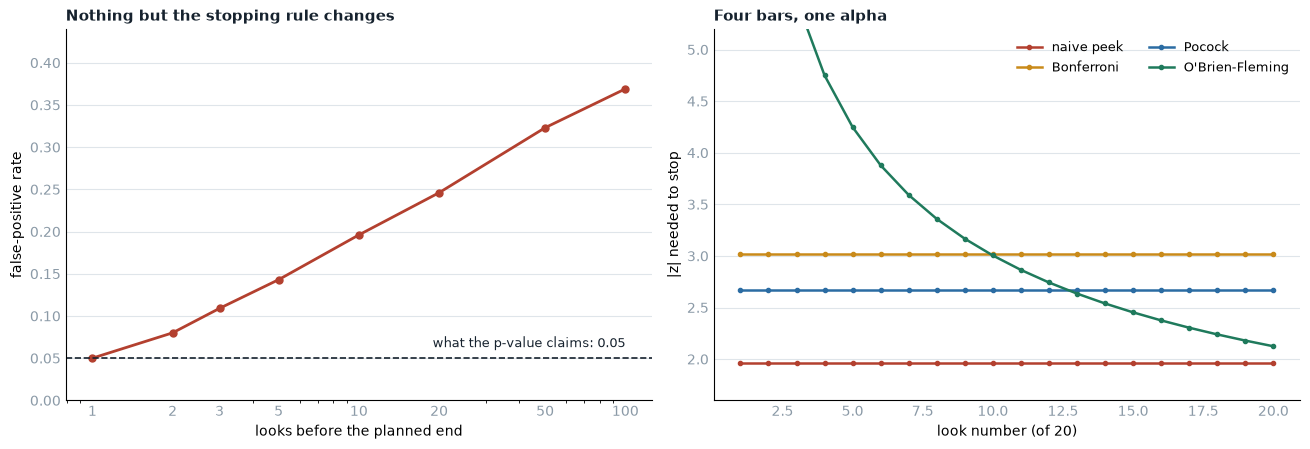

In [5]:
import matplotlib.pyplot as plt

INK, MUTE, BAD, COOL, GOOD, WARN, GRID = ("#16222e", "#8b9aa7", "#b3402f",
                                          "#2b6ca3", "#1f7a5c", "#c98a1a", "#dfe5ea")
fig, ax = plt.subplots(1, 2, figsize=(13.2, 4.6))
fig.patch.set_facecolor("white")

ks = list(naive_tbl.index)
ax[0].plot(ks, naive_tbl["measured FPR"], "-o", color=BAD, lw=2, ms=5)
ax[0].axhline(ALPHA, color=INK, ls="--", lw=1.2)
ax[0].text(100, ALPHA + 0.013, "what the p-value claims: 0.05", ha="right", fontsize=9, color=INK)
ax[0].set_xscale("log"); ax[0].set_xticks(ks); ax[0].set_xticklabels(ks)
ax[0].set_xlabel("looks before the planned end"); ax[0].set_ylabel("false-positive rate")
ax[0].set_title("Nothing but the stopping rule changes", fontsize=11, fontweight="bold",
                color=INK, loc="left")
ax[0].set_ylim(0, 0.44)

x = np.arange(1, K_DAILY + 1)
for name, b, c in (("naive peek", naive_bounds(K_DAILY), BAD),
                   ("Bonferroni", bonferroni_bounds(K_DAILY), WARN),
                   ("Pocock", pocock_bounds(K_DAILY), COOL),
                   ("O'Brien-Fleming", obf_bounds(K_DAILY), GOOD)):
    ax[1].plot(x, b, "-o", ms=3, lw=1.8, color=c, label=name)
ax[1].set_ylim(1.6, 5.2); ax[1].legend(frameon=False, fontsize=9, ncol=2)
ax[1].set_xlabel("look number (of 20)"); ax[1].set_ylabel("|z| needed to stop")
ax[1].set_title("Four bars, one alpha", fontsize=11, fontweight="bold", color=INK, loc="left")

for a in ax:
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(True, axis="y", color=GRID, lw=0.8); a.set_axisbelow(True)
    a.tick_params(colors=MUTE, length=0)
fig.tight_layout()
fig.savefig("peek_fpr_and_boundaries.png", dpi=150, facecolor="white")
plt.show()

## 4. Four corrections, one schedule

Twenty looks, 20,000 visitors per arm at the end. The null world gives the
false-positive rate; a world with a real 10% relative lift gives power and the traffic
actually consumed. `E[N]` is the honest cost column: a rule that stops early spends
less, which is the entire reason to run a sequential design rather than just refusing
to look.

In [6]:
looks = equal_looks(K_DAILY)
t_null = simulate(looks, P0, P0, M, SEED + 1)
t_alt = simulate(looks, P0, P1, M, SEED + 2)
def fixed(t):
    """The same experiment as if it had been looked at exactly once, at the end."""
    return {"looks": t["looks"][-1:], "z": t["z"][:, -1:], "diff": t["diff"][:, -1:],
            "se": t["se"][:, -1:], "true_diff": t["true_diff"]}


TAU = P1 - P0

RULES = {
    "fixed horizon": lambda t: first_crossing(t["z"], naive_bounds(t["z"].shape[1])),
    "naive peek": lambda t: first_crossing(t["z"], naive_bounds(K_DAILY)),
    "Bonferroni": lambda t: first_crossing(t["z"], bonferroni_bounds(K_DAILY)),
    "Pocock": lambda t: first_crossing(t["z"], pocock_bounds(K_DAILY)),
    "O'Brien-Fleming": lambda t: first_crossing(t["z"], obf_bounds(K_DAILY)),
    f"mSPRT (tau={TAU:.3f})": lambda t: msprt_crossing(t, TAU),
}

rows = []
for name, rule in RULES.items():
    tn, ta = (fixed(t_null), fixed(t_alt)) if name == "fixed horizon" else (t_null, t_alt)
    s0, s1 = score(tn, rule(tn)), score(ta, rule(ta))
    rows.append({"rule": name, "FPR": round(s0["reject_rate"], 3),
                 "power": round(s1["reject_rate"], 3),
                 "E[N]/arm H1": int(s1["E[N]/arm"]), "E[N]/arm H0": int(s0["E[N]/arm"]),
                 "reported lift": round(s1["reported lift"], 5),
                 "overstated": f"{s1['overstated']:+.0%}",
                 "CI cov.": round(s1["CI coverage"], 3)})
compare = pd.DataFrame(rows).set_index("rule")
print(compare.to_string())

                     FPR  power  E[N]/arm H1  E[N]/arm H0  reported lift overstated  CI cov.
rule                                                                                        
fixed horizon      0.047  0.902        20000        20000        0.01060        +6%    0.949
naive peek         0.245  0.947         7407        16632        0.01545       +55%    0.939
Bonferroni         0.019  0.677        14050        19765        0.01521       +52%    0.920
Pocock             0.051  0.798        11877        19341        0.01524       +52%    0.920
O'Brien-Fleming    0.048  0.889        13643        19799        0.01194       +19%    0.942
mSPRT (tau=0.010)  0.013  0.666        14492        19867        0.01441       +44%    0.931


Read the naive row carefully. It has the **highest power** and the
**lowest sample size** in the table — which is exactly why people peek. Both of those
are the same defect as its false-positive rate. It is not a faster test, it is a
looser one.

Pocock and O'Brien–Fleming land on 0.05 and still finish early; Bonferroni-across-looks
undershoots its alpha because it ignores how similar a look is to the one before it,
and pays for that in power.

## 5. Negative result: a valid test still overstates the effect

Correct alpha is not a correct answer. Stopping the moment the estimate is extreme
enough to cross a line *selects on the estimate*, so the effect you report is the
effect that got you there. Look at the `overstated` and `CI cov.` columns in the table
above — then watch what happens as the true effect gets smaller.

In [7]:
rows = []
for rel in (0.20, 0.10, 0.05, 0.03, 0.02):
    t = simulate(equal_looks(K_DAILY), P0, P0 * (1 + rel), M, SEED + 300 + int(rel * 100))
    s_seq = score(t, first_crossing(t["z"], pocock_bounds(K_DAILY)))
    tf = fixed(t)
    s_fix = score(tf, first_crossing(tf["z"], naive_bounds(1)))
    rows.append({"true relative lift": f"{rel:.0%}", "fixed power": round(s_fix["reject_rate"], 3),
                 "Pocock power": round(s_seq["reject_rate"], 3),
                 "reported lift": round(s_seq["reported lift"], 5),
                 "overstated by": f"{s_seq['overstated']:+.0%}"})
curse = pd.DataFrame(rows).set_index("true relative lift")
print(curse.to_string())
print("\nAt low power the only runs that cross are the lucky ones, so the surviving")
print("estimate is mostly luck -- the winner's curse arriving through the stopping rule.")

                    fixed power  Pocock power  reported lift overstated by
true relative lift                                                        
20%                       1.000         1.000        0.02454          +23%
10%                       0.901         0.799        0.01523          +52%
5%                        0.376         0.257        0.01439         +188%
3%                        0.168         0.118        0.01343         +348%
2%                        0.104         0.080        0.01166         +483%

At low power the only runs that cross are the lucky ones, so the surviving
estimate is mostly luck -- the winner's curse arriving through the stopping rule.


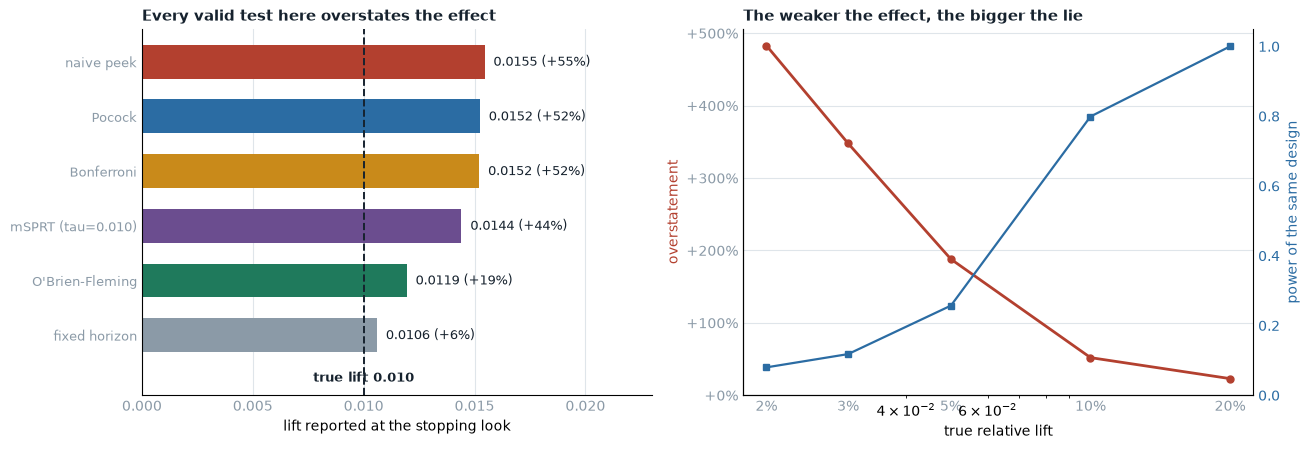

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13.2, 4.6))
fig.patch.set_facecolor("white")
COLORS = {"fixed horizon": MUTE, "naive peek": BAD, "Bonferroni": WARN, "Pocock": COOL,
          "O'Brien-Fleming": GOOD, f"mSPRT (tau={TAU:.3f})": "#6b4d8f"}

order = compare["reported lift"].sort_values().index
ax[0].barh(range(len(order)), compare.loc[order, "reported lift"],
           color=[COLORS[n] for n in order], height=0.62)
ax[0].axvline(P1 - P0, color=INK, ls="--", lw=1.4)
ax[0].text(P1 - P0, -0.85, f"true lift {P1 - P0:.3f}", ha="center", fontsize=9,
           color=INK, fontweight="bold")
for i, n in enumerate(order):
    ax[0].text(compare.loc[n, "reported lift"] + 0.0004, i,
               f"{compare.loc[n, 'reported lift']:.4f} ({compare.loc[n, 'overstated']})",
               va="center", fontsize=9, color=INK)
ax[0].set_yticks(range(len(order))); ax[0].set_yticklabels(order, fontsize=9)
ax[0].set_ylim(-1.1, len(order) - 0.4); ax[0].set_xlim(0, 0.023)
ax[0].set_xlabel("lift reported at the stopping look")
ax[0].set_title("Every valid test here overstates the effect", fontsize=11,
                fontweight="bold", color=INK, loc="left")

rel = [0.20, 0.10, 0.05, 0.03, 0.02]
bias = [float(s.strip("%+")) / 100 for s in curse["overstated by"]]
ax[1].plot(rel, bias, "-o", color=BAD, lw=2, ms=5)
ax[1].set_xscale("log"); ax[1].set_xticks(rel); ax[1].set_xticklabels([f"{r:.0%}" for r in rel])
ax[1].yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax[1].set_xlabel("true relative lift"); ax[1].set_ylabel("overstatement", color=BAD)
ax2 = ax[1].twinx()
ax2.plot(rel, curse["Pocock power"], "-s", color=COOL, lw=1.6, ms=4)
ax2.set_ylabel("power of the same design", color=COOL); ax2.set_ylim(0, 1.05)
ax2.spines["top"].set_visible(False); ax2.tick_params(colors=COOL, length=0)
ax[1].set_title("The weaker the effect, the bigger the lie", fontsize=11,
                fontweight="bold", color=INK, loc="left")

for a in ax:
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
    a.grid(True, axis="x" if a is ax[0] else "y", color=GRID, lw=0.8); a.set_axisbelow(True)
    a.tick_params(colors=MUTE, length=0)
fig.tight_layout()
fig.savefig("peek_estimate_bias.png", dpi=150, facecolor="white")
plt.show()

The ordering follows how *early* a rule may stop, not how valid it is:
Pocock is a correct 0.05 test and overstates more than O'Brien–Fleming, which is also a
correct 0.05 test. A boundary controls how often you are wrong about the **sign**. It
says nothing about the **size** — which is what the roadmap actually gets built on.

## 6. A boundary is valid for its own schedule and nothing else

A group-sequential boundary is solved for a fixed number of analyses. Add looks after
the fact — an extra mid-week check, a stakeholder refreshing the dashboard — and the
guarantee is gone silently, because the number on the screen still says 0.05.

The O'Brien–Fleming *shape* survives, because re-indexing it by information fraction
is the alpha-spending construction (Lan & DeMets 1983). The Pocock *constant* does not.
mSPRT never needed the schedule at all — its guarantee holds over every stopping time
simultaneously — but that generality has a price, and the price is `tau`.

In [9]:
c = float(pocock_bounds(K_DAILY)[0])
t40 = simulate(equal_looks(2 * K_DAILY), P0, P0, M, SEED + 5)
obf_reindexed = obf_bounds(K_DAILY)[-1] / np.sqrt(np.arange(1, 2 * K_DAILY + 1) / (2 * K_DAILY))

print("A boundary computed for 20 looks, then run at 40:")
print(f"  Pocock constant {c:.3f} held at 40 looks      FPR "
      f"{float((first_crossing(t40['z'], np.full(2 * K_DAILY, c)) >= 0).mean()):.3f}")
print(f"  OBF shape re-indexed by information fraction  FPR "
      f"{float((first_crossing(t40['z'], obf_reindexed) >= 0).mean()):.3f}")
print(f"  mSPRT, same tau, 40 looks                     FPR "
      f"{float((msprt_crossing(t40, TAU) >= 0).mean()):.3f}")

rows = []
for tau in (0.002, 0.005, 0.010, 0.020, 0.050):
    rows.append({"tau": tau, "tau / true effect": f"{tau / (P1 - P0):.1f}x",
                 "FPR": round(float((msprt_crossing(t_null, tau) >= 0).mean()), 3),
                 "power": round(float((msprt_crossing(t_alt, tau) >= 0).mean()), 3),
                 "E[N]/arm H1": int(score(t_alt, msprt_crossing(t_alt, tau))["E[N]/arm"])})
print("\nmSPRT never needed a schedule -- but tau is a real choice:")
print(pd.DataFrame(rows).set_index("tau").to_string())

A boundary computed for 20 looks, then run at 40:
  Pocock constant 2.670 held at 40 looks      FPR 0.065
  OBF shape re-indexed by information fraction  FPR 0.055
  mSPRT, same tau, 40 looks                     FPR 0.016

mSPRT never needed a schedule -- but tau is a real choice:
      tau / true effect    FPR  power  E[N]/arm H1
tau                                               
0.002              0.2x  0.000  0.100        19795
0.005              0.5x  0.005  0.594        16246
0.010              1.0x  0.013  0.666        14492
0.020              2.0x  0.015  0.630        14455
0.050              5.0x  0.010  0.537        15502


## 7. Futility is the free half nobody implements

Every rule so far only stops early on a **win**. The other reason to stop is that
nothing is happening — and unlike a success boundary, a futility boundary cannot
manufacture a false positive, because it only ever ends runs that were not going to
reject anyway. The rule here is the one teams already apply informally: from the
halfway look onward, if it is flat or negative, kill it.

In [10]:
def run_with_futility(t, reject_bounds, futility_from=None):
    """Stop for success OR because it is flat/negative. A futility boundary can
    never add a false positive -- it only ends runs that were not going to reject."""
    z = t["z"]
    n_sims, K = z.shape
    rej = np.full(n_sims, -1)
    stop = np.full(n_sims, K - 1)
    live = np.ones(n_sims, dtype=bool)
    for k in range(K):
        win = live & (np.abs(z[:, k]) >= reject_bounds[k])
        rej[win], stop[win] = k, k
        live &= ~win
        if futility_from is not None and futility_from <= k < K - 1:
            dead = live & (z[:, k] < 0)
            stop[dead] = k
            live &= ~dead
    return rej, t["looks"][stop].mean(), float((rej >= 0).mean())

rows = []
for name, b in (("Pocock", pocock_bounds(K_DAILY)), ("O'Brien-Fleming", obf_bounds(K_DAILY))):
    for label, ff in ((f"{name}, success only", None), (f"{name} + futility at z<0", K_DAILY // 2 - 1)):
        _, n0, fpr = run_with_futility(t_null, b, ff)
        _, n1, pwr = run_with_futility(t_alt, b, ff)
        rows.append({"design": label, "FPR": round(fpr, 3), "power": round(pwr, 3),
                     "E[N]/arm H0": int(n0), "E[N]/arm H1": int(n1)})
print(pd.DataFrame(rows).set_index("design").to_string())
print("\nThe saving lands exactly where it should: on the experiments with nothing in them.")

                                     FPR  power  E[N]/arm H0  E[N]/arm H1
design                                                                   
Pocock, success only               0.051  0.798        19341        11877
Pocock + futility at z<0           0.044  0.797        13419        11746
O'Brien-Fleming, success only      0.048  0.889        19799        13643
O'Brien-Fleming + futility at z<0  0.024  0.886        13743        13511

The saving lands exactly where it should: on the experiments with nothing in them.


## 8. What the experiment report should say

Not "p = 0.03". A p-value is a statement about a **procedure**, so the procedure has to
be in the report:

| what to state | why |
|---|---|
| the look schedule, fixed before the test | the false-positive rate depends on it, and on nothing else in the data |
| the boundary and the alpha it spends | 0.05 checked twenty times is not 0.05 |
| the effect with a bias adjustment | the number that tripped the boundary is the number that got lucky |
| the traffic actually consumed | this is the thing a sequential design buys you |

One line to take away: **peeking is not cheating, and it is not free.** It is a design
choice that has to be priced before the experiment starts — because the boundary that
makes it valid cannot be chosen after you have looked.

In [11]:
# Try your own experiment. Nothing here needs data or a key -- change the world
# and the tables above change with it.
#
# YOUR_P0 = 0.03          # a low-conversion funnel makes every rate noisier
# YOUR_LIFT = 0.05        # a 5% relative lift is where most real tests live
# YOUR_N = 50_000         # visitors per arm you can actually get
# YOUR_LOOKS = 30         # how many times somebody will refresh the dashboard
#
# t_null_you = simulate(equal_looks(YOUR_LOOKS, YOUR_N), YOUR_P0, YOUR_P0, M, 7)
# t_alt_you = simulate(equal_looks(YOUR_LOOKS, YOUR_N), YOUR_P0,
#                      YOUR_P0 * (1 + YOUR_LIFT), M, 8)
# for name, b in (("naive", naive_bounds(YOUR_LOOKS)),
#                 ("Pocock", pocock_bounds(YOUR_LOOKS)),
#                 ("O'Brien-Fleming", obf_bounds(YOUR_LOOKS))):
#     s0 = score(t_null_you, first_crossing(t_null_you["z"], b))
#     s1 = score(t_alt_you, first_crossing(t_alt_you["z"], b))
#     print(f"{name:<18} FPR {s0['reject_rate']:.3f}  power {s1['reject_rate']:.3f}  "
#           f"E[N] {s1['E[N]/arm']:,.0f}  overstated {s1['overstated']:+.0%}")
#
# Two things to watch for. (1) The naive FPR depends on the NUMBER of looks, not
# the calendar -- ten looks in a day costs the same as ten looks in ten days.
# (2) The lower your power, the more the reported lift overstates the truth, so
# an underpowered sequential test is worse than an underpowered fixed one.

---

**Built by Phoebe Fu** · Day 164 of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) portfolio ·
[project README](README.md)

The repo version adds `evidence.py` (the full run, ~11s), `test_sequential.py`
(45 assertions), a six-panel figure, and a Streamlit app that re-prices any schedule
you type in:

```bash
pip install -r requirements.txt
python evidence.py
python -m pytest test_sequential.py -q
streamlit run app.py
```
